# The NCrystal MiniMC simulation engine
NCrystal ships with a builtin stepping Monte Carlo, which allows to model effects of multiple scattering and geometry as neutrons are going through a simple geometry consisting of a single convex volume (box, sphere, cylinder, or slab) filled with a single homogenous material. In this notebook we will give a few basic examples of how this might be used via the Python API. Note that on the commandline, the `ncrystal_minimc` command also provides access to the MiniMC engine. Run `ncrystal_minimc --help` for more information.

## Preamble
Install dependencies and prepare plots. Feel free to edit as you wish:

In [1]:
#By default we only do pip installs on Google Colab, but you
#can set the variable in the next line to True if you need it:
always_do_pip_installs = False
try:
    import google.colab as google_colab
except ModuleNotFoundError:
    google_colab=None#not on google colab
if always_do_pip_installs or google_colab:
    %pip -q install ncrystal[plot] ipympl
#enable inline and interactive matplotlib plots:
if google_colab:
    google_colab.output.enable_custom_widget_manager()
    %matplotlib inline
else:
    %matplotlib ipympl
import matplotlib
matplotlib.rcParams.update({"figure.autolayout": True})
#always import NCrystal:
import NCrystal as NC
assert NC.version_tuple >= (4,2,13), "too old NCrystal found"
NC.test() #< quick unit test that installation works

Tests completed succesfully


# Introduction
First import NCrystal and the minimc module:

In [2]:
import NCrystal as NC
assert NC.version_tuple >= (4,2,13), "too old NCrystal version"
import NCrystal.minimc as mmc

We shall do a few quick demonstrations of how the MiniMC can be used. For reference, note that there are several ways to access more information about this. For instance one might visit the documentation at https://github.com/mctools/ncrystal/wiki/minimc. But documentation is also available inline. For reference, we note that one might uncomment and run any of the following statements to access documentation directly here in this notebook:

In [3]:
#help(mmc)
#mmc.gen_doc('src')
#mmc.gen_doc('geom')
#mmc.gen_doc('engine')
#mmc.gen_doc('scenario')

# Basic usage
Here we will be running the MiniMC engine with an NCrystal cfg-string, here representing a Zinc Oxide powder at room temperature:

In [4]:
mmc.run('ZnO_sg186_ZincOxide.ncmat;temp=300K')

MMCResults(srccfg="circular;n=1e6;z=-0.02008635;wl=4.5079;r=0.02008635",geomcfg="sphere;r=0.02008635",enginecfg="")

So what happened? Well, we ran a MiniMC simulation and got the results back in an MMCResults object. We can also see that although we didn't specify any particular neutron source or material geometry, NCrystal selected something which was hopefully "interesting". In this case, what was chosen was to send a uniform circular beam of ~4.5Aa neutrons through a ~2cm radius sphere. For actual scientific work, one will of course almost always want to perform a more careful configuration, and we will show how to do that later.

For now, let us run the simulation again and this time capture the results in a variable so we can investigate them a bit. As an example, we will plot the default tally, which is the scattering angle of the neutrons. Note that neutrons are tallied as they leave the geometry (in this case a sphere filled with our zinc oxide):

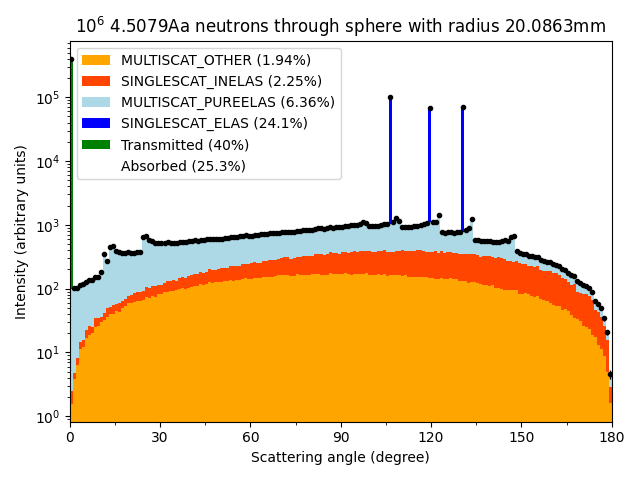

In [5]:
results_ZnO = mmc.run('ZnO_sg186_ZincOxide.ncmat;temp=300K')
results_ZnO.plot()

Here above we see 3 distinct Bragg peaks due to neutrons undergoing a single elastic scattering, and in red the contribution of neutrons undergoing a single inelastic scattering. In light-blue are shown several spurious "peaks" which are due to neutrons undergoing multiple elastic scatterings on the 3 primary peaks. Finally, in orange is the contribution from multiple scattering events which involves at least one inelastic scattering.

The above histogram depends on the parameters of the incoming (source) neutrons, the simulation geometry, and of course the NCrystal model of the neutron interactions in the chosen material. To investigate the latter, one could also feed the material cfg-string to the `plot_xsect` function from the `NCrystal.plot` module. For convenience, the MiniMC results object contains a `plot_xsect` method which does just that:

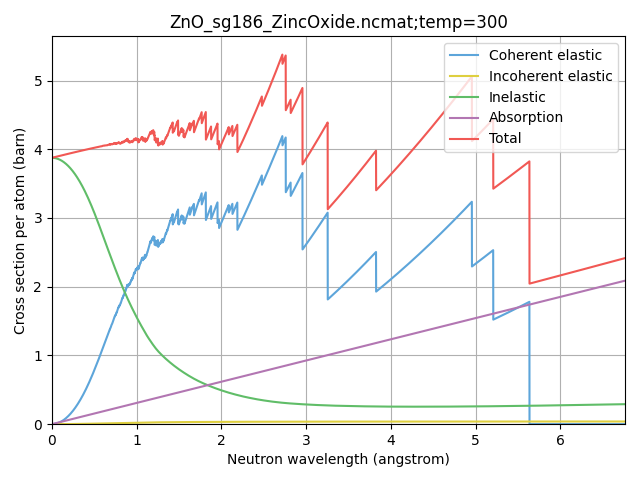

In [6]:
results_ZnO.plot_xsect()

## Specifying source and geometry
Now, let us modify the source and geometry. To do so, one can supply two configuration string: one for the neutron source (`srccfg`), and on for the geometry (`geomcfg`). Alternatively, one can for convenience use a single `scenario` configuration string. For instance, one can simulate a scenario in which a pencil beam of 1e5 neutrons of wavelength 5.5Aa impinge upon a sphere of diameter 2cm by running:

In [7]:
results_ZnO_v2 = mmc.run('ZnO_sg186_ZincOxide.ncmat;temp=300K',
                         scenario='5.5Aa pencil on 2cm sphere 1e5 times')

We can of course plot the results and see the change:

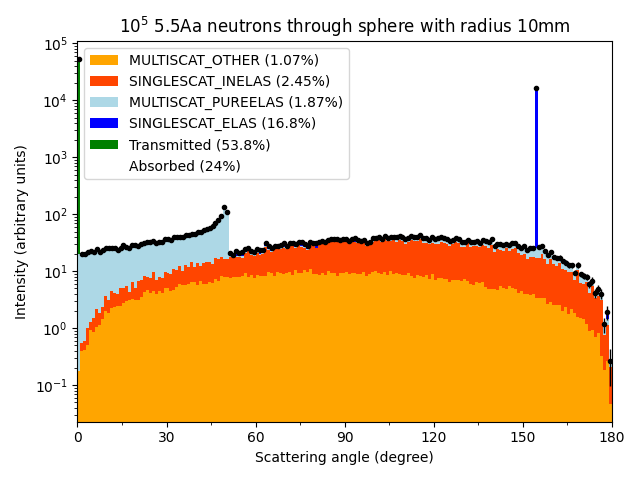

In [8]:
results_ZnO_v2.plot()

But we can also verify by simply inspecting the setup actually used, by looking in the dictionary available through the `.setup` property:

In [9]:
print(results_ZnO_v2.setup['src']['cfgstr'])
print(results_ZnO_v2.setup['geom']['cfgstr'])

constant;n=1e5;z=-0.01;wl=5.5
sphere;r=0.01


The scenario cfg-strings are mostly intended for quick usage (for instance at the cmd-line when using the `ncrystal_minimc` command). For more information visit https://github.com/mctools/ncrystal/wiki/minimc_scenario or uncomment and run:

In [10]:
#mmc.gen_doc('scenario')

## Accessing results
Now, let us dive a bit more into how one can access and use MiniMC results. First of all, note that in addition to histograms of tallied quantities, overall statistics count is available on the `.output_metadata` property, which lets us know how many (`count`) and with what flux (`weight`) neutrons were generated by the source, missed the geometry, or were available for the tally. Note, that neutrons absorbed inside the geometry will reduce the tallied flux. Also note that variance-reduction tricks like splitting of particle histories are used, so the number (`count`) of neutrons tallied will usually be higher than the number of neutrons emitted from the source:

In [11]:
results_ZnO_v2.output_metadata

{'provided': {'count': 100000, 'weight': 100000.0},
 'miss': {'count': 0, 'weight': 0.0},
 'tallied': {'count': 416882, 'weight': 75955.58412911497}}

In addition to merely plotting tally histograms, we can of course also access them programmatically as the following code examples show:

In [12]:
print("Available tallies:")
print(results_ZnO_v2.tally_names)
t_theta = results_ZnO_v2.tally('theta')
print(type(t_theta))
#Uncomment for documentation:
#help( t_theta) )

Available tallies:
['theta']
<class 'NCrystal.minimc_objects.MMCTallyView'>


We can also get a bit of information by the `.dump(..)` method:

In [13]:
t_theta.dump()

Hist1D(nbins=180,xmin=0,xmax=180):
  title     : theta
  integral  : 75955.6
  mean      : 39.6376
  rms       : 65.3633
  minfilled : 0
  maxfilled : 179.8133604445793878
  underflow : 0 +- 0
  overflow  : 0 +- 0


And we can access histograms as well, either one of the components (like `SINGLESCAT_ELAS`) or the `total`. This then allows us to access bin contents:

In [14]:
t_theta.histograms

{'total': <NCrystal.hist.Hist1D at 0x7a0614b411f0>,
 'NOSCAT': <NCrystal.hist.Hist1D at 0x7a0614b40e60>,
 'SINGLESCAT_ELAS': <NCrystal.hist.Hist1D at 0x7a0614b42150>,
 'SINGLESCAT_INELAS': <NCrystal.hist.Hist1D at 0x7a0614b431a0>,
 'MULTISCAT_PUREELAS': <NCrystal.hist.Hist1D at 0x7a0614b42cc0>,
 'MULTISCAT_OTHER': <NCrystal.hist.Hist1D at 0x7a0614b41a30>}

In [15]:
import pprint
h_sglelas = t_theta.histograms['SINGLESCAT_ELAS']
print( h_sglelas.binning )
print( h_sglelas.contents )
print( h_sglelas.errors )

(180, 0.0, 180.0)
[0.00000000e+00 2.12539304e-01 1.82036822e-01 1.76367742e-01
 5.01056593e-01 1.72540980e-01 7.56399781e-01 0.00000000e+00
 6.95575112e-01 7.46202095e-01 5.29346800e-01 3.92435533e-01
 5.03007880e-01 1.97550985e-01 9.02245737e-01 1.09304018e+00
 1.09552641e+00 3.79539752e-01 1.07350453e+00 1.28959048e+00
 7.29108729e-01 9.16927905e-01 7.21202735e-01 1.44347087e+00
 9.48953940e-01 1.62942925e+00 2.06040544e+00 5.35232260e-01
 1.38402425e+00 2.20226181e+00 1.82237993e+00 1.80738600e+00
 1.48146863e+00 2.03095880e+00 5.89609338e-01 1.90349786e+00
 2.24530237e+00 1.98372623e+00 1.86724497e+00 2.52910191e+00
 1.83414416e+00 1.25888396e+00 3.10364748e+00 2.05436531e+00
 2.02226341e+00 2.99797069e+00 2.94798880e+00 3.07041231e+00
 1.88669936e+00 1.32793422e+00 1.88407545e+00 2.24588743e+00
 9.44281887e-01 4.15941048e+00 1.69115172e+00 3.21787583e+00
 2.24158212e+00 2.27537101e+00 2.64789461e+00 1.89436743e+00
 2.69770041e+00 3.40923504e+00 2.71042842e+00 3.21200737e+00
 2.843

## Configuring tallies
Next, assume we want to tally something else than the scattering angle. For instance, the energy loss (`de`). For that we have to use the `enginecfg` string, and add the quantities we want to tally as a comma separated list using the `tally` keyword. For this example, let us tally `de` in addition to the scattering angle (`theta`): 

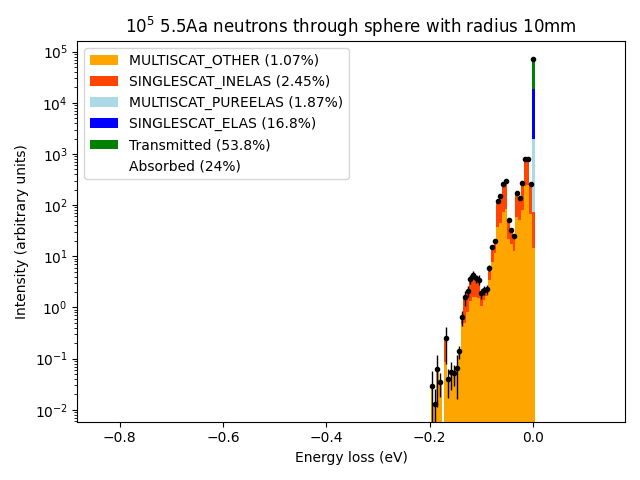

In [16]:
results_ZnO_v3 = mmc.run('ZnO_sg186_ZincOxide.ncmat;temp=300K',
                         scenario='5.5Aa pencil on 2cm sphere 1e5 times',
                         enginecfg='tally=de,theta')
#Uncomment next line to plot both "de" and "theta" histograms:
#results_ZnO_v3.plot()#
#Here is how to plot just "de":
results_ZnO_v3.tally('de').plot()

In the plot above, we might not be happy with the chosen histogram binning. We can use the `tallybins` parameter to override it:

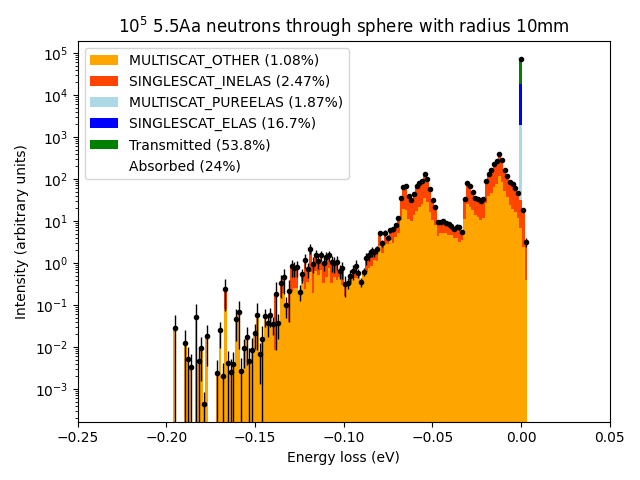

In [17]:
results_ZnO_v4 = mmc.run('ZnO_sg186_ZincOxide.ncmat;temp=300K',
                         scenario='5.5Aa pencil on 2cm sphere 1e5 times',
                         enginecfg='tally=de,theta;tallybins=de:200:-0.25:0.05')
#Uncomment next line to plot both "de" and "theta" histograms:
#results_ZnO_v3.plot()#
#Here is how to plot just "de":
results_ZnO_v4.tally('de').plot()

There are many more things that can be tuned in the enginecfg string. Access more information about it by uncommenting and running the next line:

In [18]:
#mmc.gen_doc('engine')

Likewise, for more advanced usage one will typically want to specify `srccfg` and `geomcfg` strings rather than just the scenario strings we saw above. For more information about this, uncomment and run the lines below:

In [19]:
#mmc.gen_doc('src')
#mmc.gen_doc('geom')

# Saving results
Under the hood the output of a MiniMC run is actually a JSON string containing a dictionary with all the information related to the run (both configuration data and output). The `MMCResults` class that we have been manipulating so far, is actually just a thin convenience wrapper around this dictionary. For that reason, results can be easily saved to a file and loaded at a later point. This might be useful if a large-statistics run required a significant running time. As an example, here is how one converts a results object to a JSON string:

In [20]:
my_json_data = results_ZnO.to_json()
print( type(my_json_data), len(my_json_data) )

<class 'str'> 40736


So around 40kB of data in this case. Here is how it is converted back and used:

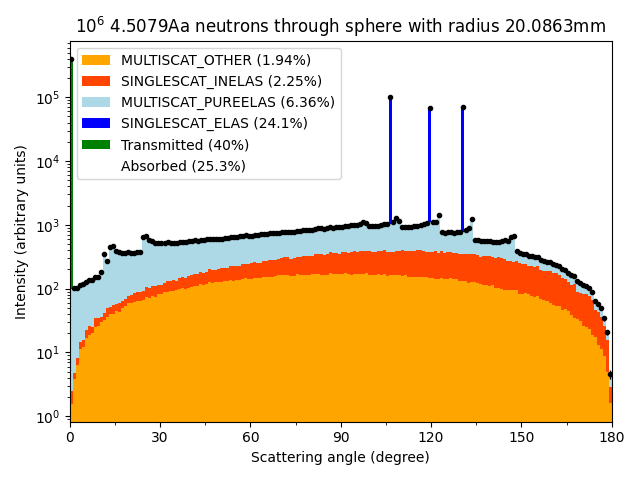

In [21]:
results_reloaded = mmc.MMCResults(my_json_data)
results_reloaded.plot()

If desired, the JSON data can be saved and loaded to a file using the `pathlib` module's `Path.write_text` and `Path.read_text` methods. For instance:

In [22]:
import pathlib
#Store the data:
pathlib.Path('./my_minimc_results.json').write_text(my_json_data)
#Load the data again later:
results = mmc.MMCResults( pathlib.Path('./my_minimc_results.json').read_text() )

# Using a callback function

In case the predefined tally quantities are not enough, it is also possible to simply get access to all the tallied neutron data. This is done by defining a custom callback function which will be called by the MiniMC engine while the simulation is running. For full efficiency, neutron states are provided as numpy arrays, allowing large-scale processing in Python code in an efficient fashion. Let us show how this works by the following example in which we will print all the received data. To not overflow this notebook, we will run with a very low number of neutrons:

I got some data!
{'x': array([ 0.00186843, -0.00372268,  0.00245336,  0.00070408,  0.00208096,
       -0.00465966, -0.00301546]),
 'y': array([-0.00446269,  0.00232854, -0.00236416,  0.0012736 , -0.00454009,
        0.00045797,  0.00344223]),
 'z': array([ 0.0012623 ,  0.00239156, -0.00365948, -0.00478353,  0.00023906,
        0.00175438, -0.00201446]),
 'ux': array([ 0.        ,  0.        ,  0.14519323,  0.52602917,  0.31088551,
       -0.70392816,  0.22517288]),
 'uy': array([ 0.        ,  0.        ,  0.52090327, -0.12535791, -0.20159667,
       -0.35840838,  0.62287431]),
 'uz': array([ 1.        ,  1.        , -0.84117698, -0.84117698,  0.92882129,
        0.61321169, -0.7492161 ]),
 'ekin': array([0.00566511, 0.00566511, 0.00566511, 0.00566511, 0.00566511,
       0.00566511, 0.00566511]),
 'w': array([0.94269815, 0.89422438, 0.05171329, 0.08611231, 0.00498983,
       0.01691353, 0.00148073]),
 'nscat': array([0., 0., 1., 1., 2., 2., 3.]),
 'nscat_inelas': array([0., 0., 0., 0., 

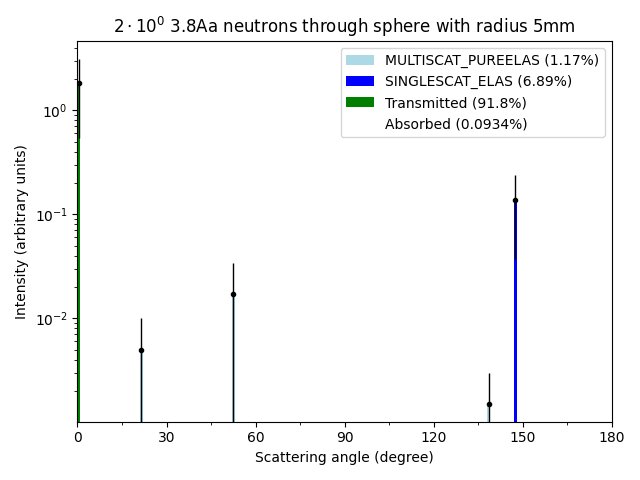

In [23]:
import pprint
def mycallbackfct( data ):
    print("I got some data!")
    pprint.pp(data)
results_callback = mmc.run('Be_sg194.ncmat',
                           scenario='3.8Aa on 1cm sphere 2 times',
                           callback = mycallbackfct)
results_callback.plot()

Several points can already be made based on this little example.

First of all, we still got the usual results object back via the `mmc.run(..)` return value, and could use it to plot the scattering angle tally just as we did previously. Thus, the presence or absence of a callback function does not otherwise alter how one configures a simulation or what results are returned. It merely gives us a way to spy on the neutrons via the callback function.

We saw how the callback function gets the data as a dictionary where the keys are names of neutron state parameters ('x','y','z','ekin',...) and the values are 1D Numpy arrays with the values. All the 1D arrays have the same length, and this length is the number of neutrons in that callback.

We didn't see it in this low statistics run, but the callback function will usually get invoked more than once. Let us try to see this in an example with more normal statistics:

In [24]:
def mycallbackfct( data ):
    print("mycallbackfct: I got %i neutrons"%len(data['ekin']))
results_callback = mmc.run('Be_sg194.ncmat',
                           scenario='3.8Aa on 1cm sphere 1e6 times',
                           callback = mycallbackfct)

mycallbackfct: I got 261264 neutrons
mycallbackfct: I got 261723 neutrons
mycallbackfct: I got 261690 neutrons
mycallbackfct: I got 260873 neutrons
mycallbackfct: I got 261709 neutrons
mycallbackfct: I got 262144 neutrons
mycallbackfct: I got 260867 neutrons
mycallbackfct: I got 260918 neutrons
mycallbackfct: I got 262144 neutrons
mycallbackfct: I got 262144 neutrons
mycallbackfct: I got 262144 neutrons
mycallbackfct: I got 262144 neutrons
mycallbackfct: I got 262144 neutrons
mycallbackfct: I got 259083 neutrons
mycallbackfct: I got 63056 neutrons


So we see we got called several times, everytime (except possibly the last) with a very large number of neutrons (to have arrays long enough to treat efficiently in Python). The reason we do not simply provide a single call to the callback function with all the neutrons, is of course that this could result in too large memory requirements.

Now let us do something a bit more useful. Assume we want to obtain the energy distribution of neutrons transmitted through a 1cm slab of polyethylene and headed within 10degrees of the forward direction. This particular criteria can not be accessed via one of the standard tallies, but can be found via the callback function.

Naturally, it is up to the user how to collect and analyse the data passed to the callback function, but here we will create histograms with the help of a utility class `HistFiller1D` from NCrystal.

mycallbackfct: I got 260043 neutrons (using 8.9%)
mycallbackfct: I got 259786 neutrons (using 7.3%)
mycallbackfct: I got 258649 neutrons (using 5.1%)
mycallbackfct: I got 259925 neutrons (using 5.6%)
mycallbackfct: I got 259360 neutrons (using 3.7%)
mycallbackfct: I got 259828 neutrons (using 5.1%)
mycallbackfct: I got 259559 neutrons (using 4.0%)
mycallbackfct: I got 261242 neutrons (using 4.7%)
mycallbackfct: I got 258438 neutrons (using 0.7%)
mycallbackfct: I got 262144 neutrons (using 0.8%)
mycallbackfct: I got 250895 neutrons (using 0.8%)
mycallbackfct: I got 244706 neutrons (using 0.7%)
mycallbackfct: I got 196912 neutrons (using 0.8%)


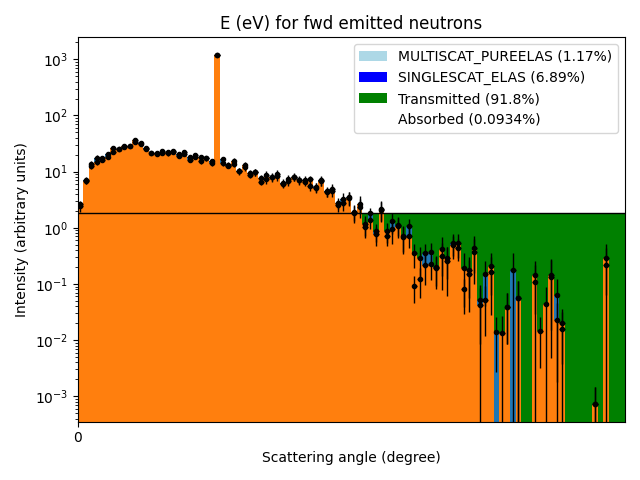

In [26]:
from NCrystal.hist import HistFiller1D
import math
h = HistFiller1D( 100, 0.0, 0.1, "E (eV) for fwd emitted neutrons")
def mycallbackfct( data ):
    mask = data['uz'] > math.cos(10.0*math.pi/180)
    n, nused = len(data['ekin']), mask.sum()
    print("mycallbackfct: I got %i neutrons (using %.1f%%)"%(n,nused*100.0/n))
    h.fill( data['ekin'][mask], data['w'][mask] )
results_callback = mmc.run('Polyethylene_CH2.ncmat;temp=100K',
                           scenario='25meV on 1cm slab 1e5 times',
                           callback = mycallbackfct)
#to plot our custom histogram we convert the HistFiller1D object
#to a Hist1D object via .to_hist1D() and then call plot:
plt = h.to_hist1d().plot(logy=True)

So this is how a callback function could be used. Notice btw. that the fraction of neutrons fulfilling our directional `fwd` criteria of `uz>cos(10degree)` is not constant when we are getting callbacks. This is due to our neutron splitting and variance reduction schemes. Thus, to avoid bias it is important to always let the run finish and include neutrons from all callback invocations equally. It *is* however possible to let the run terminate dynamically once "enough" statistics has been acquired. Simply return `True` from the callback function, and the neutron source will instantely "dry up" even though the originally requested number of source neutrons has not been delivered. Any lingering neutrons already in the system will however be allowed to carry on with their scatterings and be tallied as usual. This is intended to avoid any sort of bias which might otherwise result from the simulation being aborted immediately.

# Command-line interface
For completeness, we mention here that it is also possible to launch the MiniMC directly from a terminal interface as well. This is done using the `ncrystal_minimc` command.

To try it out, please open a terminal and type the command:
```
ncrystal_minimc "Al_sg225.ncmat" "4Aa on 1cm sphere"`.
```
If you get an error like `Command 'ncrystal_minimc' not found`, it might be because you have to first install (or update) NCrystal, or perhaps activate a Python VENV or a CONDA environment in which NCrystal has been installed.

To get more detailed usage information, run the command:
```
ncrystal_minimc --help
```
Or for even more information:
```
ncrystal_minimc --full-help
```
This can of course also be done from this notebook, and this is how it looks:

In [27]:
!ncrystal_minimc --help

usage: ncrystal_minimc [-h] [--full-help] [--tally TALLIES] [--plot]
                       [CFGSTR] [SCENARIO]

Run a simulation with NCrystal's builtin MiniMC framework, in order to
investigate neutron scattering in various geometries, including effects of
multiple scattering.

Quick examples of how to use:

  1. $> ncrystal_minimc Al_sg225.ncmat
  2. $> ncrystal_minimc "Al_sg225.ncmat;temp=300K" "2Aa pencil on 2mm sphere"
  3. $> ncrystal_minimc "Be_sg194.ncmat;temp=80K" "10meV on 2mm sphere"
  4. $> ncrystal_minimc gasmix::air/0.9relhumidity "1.8Aa on 10cm slab"
  5. $> ncrystal_minimc C_sg194_pyrolytic_graphite.ncmat "0.99BT on 2mfp 1e5 times"

Run with --full-help for full list of options and more detailed instructions.

positional arguments:
  CFGSTR               NCrystal cfg-string defining sample material.
  SCENARIO             String defining the simulation geometry and neutron source
                       in terms of a simple scenario. For more detailed control,
         

# Get more information

To get more information about the NCrystal MiniMC, refer to the wiki at:
https://github.com/mctools/ncrystal/wiki/minimc

Alternatively, you can as already mentioned also access information directly from Python (like here in this notebook), by uncommenting and running the following commands:

In [28]:
#help(mmc)
#mmc.gen_doc('src')
#mmc.gen_doc('geom')
#mmc.gen_doc('engine')
#mmc.gen_doc('scenario')

Finally you can, as already mentioned, also access more information about the `ncrystal_minimc` command by running `ncrystal_minimc --help` or `ncrystal_minimc --full-help` from a terminal.